# 03 · Integridad tarifaria

**Objetivo:** identificar viajes cuyo cobro no es consistente con el tarifario, con su ruta o con sus propios componentes, y estimar el dinero involucrado, para priorizar revisiones.

Este notebook reemplaza la detección de anomalías del curso (Z-score, IQR, Isolation Forest y LOF). Con variables tan sesgadas, ningún umbral estadístico distingue un viaje largo legítimo de un error; en cambio, el tarifario de la TLC define con precisión qué cobros son posibles. Las reglas viven en `src/nyc_taxi_ops/auditoria.py`.

Una marca **no prueba fraude**: identifica casos que un área de fiscalización revisaría primero.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nyc_taxi_ops import agregados, auditoria, calidad, config, datos, graficos, imputacion, pipeline

graficos.estilo()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
reglas = list(auditoria.REGLAS)
columnas = [
    "VendorID", "fecha", "franja", "RatecodeID", "PULocationID", "DOLocationID", "pu_distrito", "do_distrito",
    "trip_distance", "duracion_min", "fare_amount", "valido_demanda", "q_tiempo_invalido", "q_monto_implausible",
    "mediana_ruta", "diferencia_total", *reglas, *[r.replace("a_", "impacto_", 1) for r in reglas],
]
base = pipeline.cargar_base(columnas)
valida = base["valido_demanda"]
print(f"Base analítica: {valida.sum():,} viajes")

Base analítica: 9,673,906 viajes


## 1. Validar el tarifario antes de usarlo como regla

Tarifa estándar de 2017: banderazo de \$2.50 y \$0.50 por cada 1/5 de milla por encima de 12 mph, o \$0.50 por cada 60 segundos en tráfico lento. El taxímetro cobra por distancia **o** por tiempo, nunca por ambos a la vez, así que la tarifa queda acotada:

$$2.50 + 2.50 \cdot \text{millas} \;\le\; \text{tarifa} \;\le\; 2.50 + 2.50 \cdot \text{millas} + 0.50 \cdot \text{minutos}$$

Si la regla describe bien el sistema de cobro, casi todos los viajes estándar deberían caer dentro de la banda. Se verifica con los propios datos antes de usarla para auditar.

In [3]:
estandar = (
    valida & (base["RatecodeID"] == 1) & (base["trip_distance"] > 0)
    & ~base["q_tiempo_invalido"] & ~base["q_monto_implausible"] & (base["fare_amount"] > 0)
)
x = base.loc[estandar]
minimo, maximo = auditoria.limites_tarifario(x["trip_distance"].astype(float), x["duracion_min"].astype(float))

filas = []
for tolerancia in (0.0, 0.5, 1.0, 2.0):
    debajo = x["fare_amount"] < minimo - tolerancia
    encima = x["fare_amount"] > maximo + tolerancia
    filas.append({"tolerancia_usd": tolerancia, "pct_debajo": debajo.mean() * 100,
                  "pct_encima": encima.mean() * 100, "pct_dentro": (~debajo & ~encima).mean() * 100})
pd.DataFrame(filas)

,tolerancia_usd,pct_debajo,pct_encima,pct_dentro
0,0.00,2.88,0.00,97.12
1,0.50,0.04,0.00,99.96
2,1.00,0.01,0.00,99.99
3,2.00,0.01,0.00,99.99


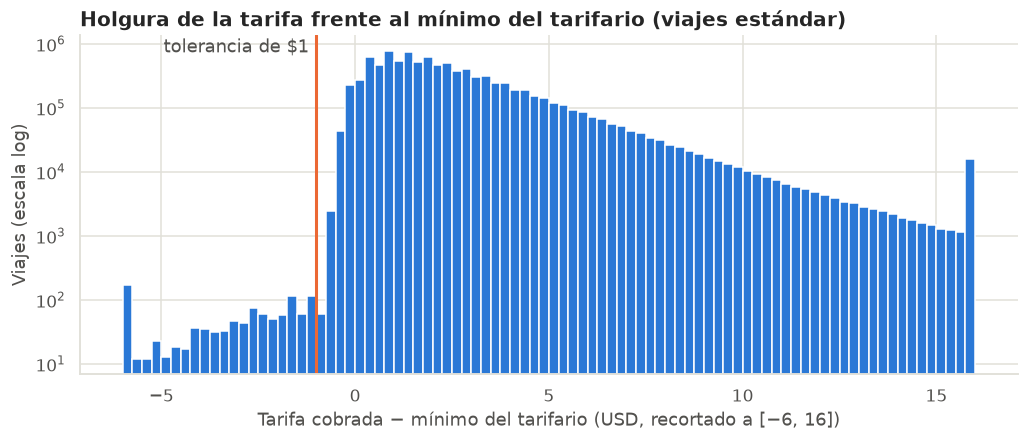

In [4]:
holgura = (x["fare_amount"] - minimo).clip(-6, 16)
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(holgura, bins=np.arange(-6, 16.25, 0.25), color=graficos.AZUL)
ax.axvline(-config.TOLERANCIA_TARIFA, color=graficos.NARANJA, lw=2)
ax.text(-config.TOLERANCIA_TARIFA - 0.2, ax.get_ylim()[1] * 0.9, "tolerancia de $1", ha="right", color=graficos.TINTA_2)
ax.set_yscale("log")
ax.set_xlabel("Tarifa cobrada − mínimo del tarifario (USD, recortado a [−6, 16])")
ax.set_ylabel("Viajes (escala log)")
ax.set_title("Holgura de la tarifa frente al mínimo del tarifario (viajes estándar)")
graficos.guardar(fig, "03_holgura_tarifario.png")
plt.show()

### Lectura

De entrada, la validación confirmó que el tarifario describe con bastante precisión el sistema de cobro, ya que sin ninguna tolerancia el 97.12% de los viajes estándar se ubica dentro de la banda, y al admitir una holgura de apenas $0.50, equivalente a un salto del taxímetro, el porcentaje sube a 99.96%. Así mismo, con la tolerancia de $1 adoptada en la regla el 99.99% de los viajes queda dentro de la banda, lo que indica que las diferencias menores corresponden a redondeos del taxímetro y no a cobros inconsistentes.

Teniendo esto en cuenta, el histograma permite observar un corte muy marcado justo en el mínimo del tarifario, por debajo del cual quedan muy pocos viajes, lo que contrasta con el enfoque del proyecto del curso, en el que umbrales estadísticos como el IQR marcaban como atípicos viajes largos pero legítimos. A diferencia de esos métodos, la regla del tarifario no depende de la forma de la distribución, sino de una restricción del propio sistema de cobro, por lo que un viaje por fuera de la banda sí representa una inconsistencia que vale la pena revisar.

## 2. Resultados por regla

In [5]:
resumen = auditoria.resumen_auditoria(base)
resumen[["regla", "viajes", "pct_base", "impacto_usd", "impacto_mediano_usd"]]

,regla,viajes,pct_base,impacto_usd,impacto_mediano_usd
0,Tarifa por debajo del mínimo del tarifario,900,0.01,"5,442.00",3.25
1,Tarifa por encima del máximo del tarifario,110,0.00,"1,009.98",2.15
2,Tarifa suburbana en un viaje dentro de NYC,1702,0.02,"19,961.27",16.50
3,Tarifa plana JFK distinta de $52,27,0.00,"1,398.00",52.00
4,Distancia atípica para la ruta,42921,0.44,"401,223.88",7.10
5,Total que no concilia con sus componentes,19162,0.20,"40,240.43",1.95
6,"Monto implausible, mayor a $1,000",9,0.00,0.00,0.00


## 3. Proveedor tecnológico

Los proveedores (Creative Mobile Technologies y VeriFone) instalan el taxímetro y el sistema de registro. Si una regla se concentra en uno solo, la causa más probable es el equipo o el software, no el comportamiento de los conductores.

In [6]:
proveedores = resumen[["regla", "tasa_10k_v1", "tasa_10k_v2"]].rename(
    columns={"tasa_10k_v1": "CMT por 10 mil", "tasa_10k_v2": "VeriFone por 10 mil"}
)
proveedores["razón CMT / VeriFone"] = proveedores["CMT por 10 mil"] / proveedores["VeriFone por 10 mil"].replace(0, np.nan)
proveedores

,regla,CMT por 10 mil,VeriFone por 10 mil,razón CMT / VeriFone
0,Tarifa por debajo del mínimo del tarifario,1.81,0.20,8.88
1,Tarifa por encima del máximo del tarifario,0.09,0.14,0.64
2,Tarifa suburbana en un viaje dentro de NYC,2.87,0.84,3.43
3,Tarifa plana JFK distinta de $52,0.02,0.04,0.51
4,Distancia atípica para la ruta,38.13,49.52,0.77
5,Total que no concilia con sus componentes,0.00,36.17,0.00
6,"Monto implausible, mayor a $1,000",0.02,0.00,9.68


### Lectura

Con respecto a la comparación entre proveedores, los resultados muestran que algunas reglas se concentran casi por completo en uno solo de ellos. Por un lado, el 100% de los totales que no concilian corresponde a VeriFone, mientras que las tarifas por debajo del mínimo del tarifario son 8.9 veces más frecuentes en Creative Mobile Technologies (1.81 frente a 0.20 casos por cada 10,000 viajes). Teniendo en cuenta que ambos proveedores operan en la misma ciudad y en el mismo periodo, una diferencia de esta magnitud apunta a fallas de captura del equipo o del software de cada proveedor, más que a un comportamiento de los conductores.

Por otro lado, la regla de distancia atípica para la ruta presenta tasas del mismo orden en ambos proveedores (38.1 frente a 49.5 casos por cada 10,000 viajes), lo cual es consistente con un fenómeno que depende del recorrido y no del equipo. A partir de lo anterior, las acciones que se derivan de la auditoría son distintas según la regla: las inconsistencias concentradas en un proveedor deberían escalarse a ese proveedor como un problema técnico, mientras que las que se distribuyen de forma similar deberían revisarse caso a caso.

## 4. Distancia atípica para la ruta (regla contextual)

Esta es la versión de negocio de las anomalías contextuales del curso: en lugar de comparar cada viaje contra todo el dataset, se compara contra los viajes del **mismo par origen-destino**. La dispersión se mide con la MAD escalada (1.4826 × MAD), que es robusta frente a valores extremos y al sesgo de la distancia (Leys et al., 2013). Se marca un viaje cuando su distancia supera la mediana de la ruta en más de 5 MAD, es al menos 1.5 veces la mediana y la excede en al menos una milla. Se excluyen los viajes dentro de una misma zona (pueden ser de ida y vuelta) y las zonas desconocidas.

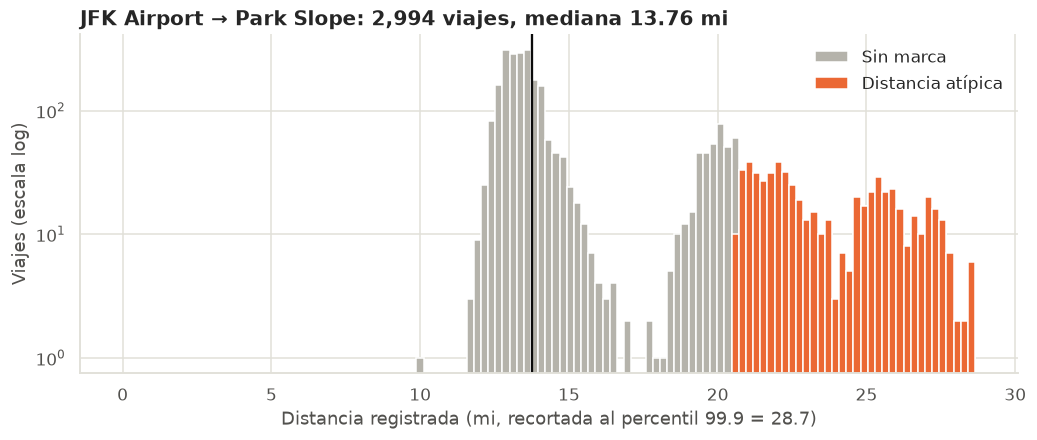

In [7]:
marcados = base.loc[base["a_desvio_ruta"]]
ruta = marcados.groupby(["PULocationID", "DOLocationID"]).size().idxmax()
en_ruta = base.loc[
    (base["PULocationID"] == ruta[0]) & (base["DOLocationID"] == ruta[1]) & valida
    & (base["RatecodeID"] == 1) & ~base["q_tiempo_invalido"] & (base["trip_distance"] > 0)
]
nombres = datos.cargar_zonas().set_index("LocationID")["zona"]
mediana = en_ruta["trip_distance"].median()
limite = en_ruta["trip_distance"].quantile(0.999)
bordes = np.linspace(0, limite, 120)

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(en_ruta["trip_distance"].clip(upper=limite), bins=bordes, color=graficos.GRIS, label="Sin marca")
ax.hist(en_ruta.loc[en_ruta["a_desvio_ruta"], "trip_distance"].clip(upper=limite), bins=bordes, color=graficos.NARANJA, label="Distancia atípica")
ax.axvline(mediana, color=graficos.TINTA, lw=1.5)
ax.legend()
ax.set_yscale("log")
ax.set_xlabel(f"Distancia registrada (mi, recortada al percentil 99.9 = {limite:.1f})")
ax.set_ylabel("Viajes (escala log)")
ax.set_title(f"{nombres[ruta[0]]} → {nombres[ruta[1]]}: {len(en_ruta):,} viajes, mediana {mediana:.2f} mi")
graficos.guardar(fig, "03_ejemplo_ruta.png")
plt.show()

In [8]:
consistentes = (~marcados["a_bajo_tarifario"]).mean()
print(f"Viajes marcados por desvío: {len(marcados):,}")
print(f"De ellos, con tarifa consistente con la distancia registrada: {consistentes:.1%}")
print(f"Millas adicionales frente a la mediana de la ruta (mediana): {(marcados['trip_distance'] - marcados['mediana_ruta']).median():.2f}")
marcados["franja"].value_counts().div(base.loc[valida, "franja"].value_counts()).mul(10_000).rename("casos por 10 mil viajes")

Viajes marcados por desvío: 42,921
De ellos, con tarifa consistente con la distancia registrada: 99.5%
Millas adicionales frente a la mediana de la ruta (mediana): 2.84


franja
Noche       41.91
Tarde       42.35
Mañana      38.79
Madrugada   72.58
Name: casos por 10 mil viajes, dtype: float64

### Lectura

En cuanto a la distancia atípica para la ruta, la regla marcó 42,921 viajes, equivalentes al 0.44% de la base, y de ellos el 99.5% tiene una tarifa consistente con la distancia registrada, esto quiere decir que en la gran mayoría de los casos el pasajero efectivamente pagó por las millas adicionales, que en la mediana son 2.84 millas por encima de lo habitual para la ruta. Adicionalmente, la tasa de casos es considerablemente mayor en la madrugada (72.6 por cada 10,000 viajes) que en el resto del día (entre 38.8 y 42.4).

Sin embargo, el ejemplo de la ruta JFK Airport → Park Slope, que es la que acumula más casos (597), muestra una distribución con dos modas, una alrededor de la mediana de 13.76 millas y otra cercana a las 20 millas, lo que sugiere la existencia de un recorrido alternativo que se usa con cierta frecuencia. Teniendo esto en cuenta, una posible explicación es que parte de los casos correspondan a recorridos más largos pero más rápidos, especialmente en la madrugada; sin embargo, esta hipótesis no se verificó directamente, por lo que la regla debe entenderse como un filtro de priorización para revisión y no como evidencia de desvío intencional.

## 5. Conciliación del total

Proveedor: {'VeriFone': 19162}

Diferencias más frecuentes (total − suma de componentes):
diferencia_total
1.95     18108
4.95       677
3.90       342
-5.54       14
9.90        12
-0.50        2


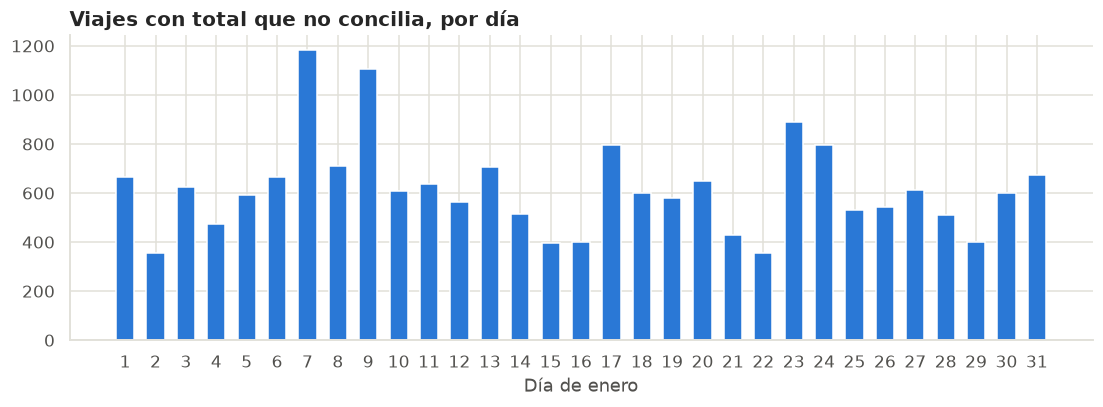

In [9]:
no_concilia = base.loc[base["a_total_no_concilia"]]
print("Proveedor:", no_concilia["VendorID"].map(config.PROVEEDORES).value_counts().to_dict())
print("\nDiferencias más frecuentes (total − suma de componentes):")
print(no_concilia["diferencia_total"].round(2).value_counts().head(6).to_string())
por_dia = no_concilia.groupby(no_concilia["fecha"].dt.day).size()
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.bar(por_dia.index, por_dia.values, color=graficos.AZUL, width=0.6)
ax.set_xticks(range(1, 32))
ax.set_xlabel("Día de enero")
ax.set_title("Viajes con total que no concilia, por día")
plt.show()

### Lectura

Con respecto a la conciliación del total, los 19,162 viajes cuyo total no coincide con la suma de sus componentes corresponden en su totalidad a VeriFone, y en el 94.5% de los casos la diferencia es exactamente de $1.95, seguida de $4.95 (677 casos) y de $3.90 (342 casos), este último equivalente al doble de $1.95. Así mismo, estos casos aparecen todos los días del mes, con entre 354 y 1,184 viajes diarios, lo que equivale a entre el 0.22% y el 0.69% de los viajes diarios de VeriFone.

Teniendo en cuenta lo anterior, la regularidad del monto y su presencia constante a lo largo del mes indican que no se trata de errores aleatorios de digitación, sino de un cargo sistemático que el sistema de VeriFone suma al total sin registrarlo en ninguno de los componentes. Si bien los datos no permiten identificar a qué concepto corresponde este cargo, el hallazgo es relevante desde el punto de vista de la auditoría, ya que implica que el total cobrado al pasajero no puede reconstruirse a partir del detalle del registro.

## 6. Tarifa suburbana dentro de la ciudad

Los códigos 3 (Newark) y 4 (Nassau/Westchester) solo aplican a viajes que salen de la ciudad. En 2010 la TLC detectó, con los datos GPS de los taxímetros, 1.8 millones de viajes dentro de la ciudad cobrados con la tarifa suburbana, que es el doble de la estándar (NBC News, 2010).

In [10]:
sub = base.loc[base["a_codigo_fuera_ciudad"]]
print(sub["RatecodeID"].map(config.CODIGOS_TARIFA).value_counts().to_string())
sub.assign(ruta=sub["pu_distrito"].astype(str) + " → " + sub["do_distrito"].astype(str)).groupby("ruta").agg(
    viajes=("fare_amount", "size"), tarifa_mediana=("fare_amount", "median"), impacto=("impacto_codigo_fuera_ciudad", "sum")
).sort_values("viajes", ascending=False).head(8)

RatecodeID
Newark                  1319
Nassau / Westchester     383


,viajes,tarifa_mediana,impacto
ruta,,,
Manhattan → Manhattan,1042,20.00,"12,998.03"
Queens → Queens,451,20.00,"5,167.73"
Brooklyn → Brooklyn,53,20.00,702.28
Manhattan → Queens,47,59.00,296.59
Queens → Manhattan,25,69.00,124.75
Queens → Bronx,19,90.00,167.22
Bronx → Bronx,18,20.75,232.20
Queens → Brooklyn,15,52.00,85.27


### Lectura

Finalmente, la regla de tarifa suburbana dentro de la ciudad identificó 1,702 viajes, de los cuales 1,319 usaron el código de Newark y 383 el de Nassau/Westchester, a pesar de que empezaron y terminaron dentro de los cinco distritos de Nueva York. El caso más frecuente son los viajes de Manhattan a Manhattan (1,042, de los cuales 829 usaron el código de Newark), que tienen una tarifa mediana de $20, frente a $8 del resto de viajes estándar dentro de Manhattan; además, su distancia mediana es de apenas 0.2 millas, frente a 1.4 millas de los viajes estándar.

Teniendo esto en cuenta, un cobro de $20 por un trayecto de 0.2 millas coincide con el valor inicial de la tarifa de Newark, que suma el banderazo de $2.50 y el recargo de $17.50 (NYC Taxi & Limousine Commission, s. f.), lo que sugiere que el código se activó en viajes que no salieron de la ciudad. Este es el mismo patrón que la TLC detectó en 2010, cuando identificó mediante los datos GPS de los taxímetros 1.8 millones de viajes dentro de la ciudad cobrados con la tarifa suburbana (NBC News, 2010); sin embargo, una distancia tan corta también podría indicar registros en los que el viaje real no quedó capturado, por lo que estos casos deben revisarse antes de concluir que hubo un cobro indebido.

## Limitaciones

- Una tarifa por debajo del mínimo puede deberse a una distancia mal registrada y no a un cobro incompleto.
- La regla de desvío usa la mediana del par de zonas como referencia; el tráfico o un cierre vial pueden justificar un recorrido más largo.
- El impacto en dólares es una estimación con supuestos explícitos (ver `auditoria.REGLAS`), no una cifra contable.

## Conclusiones

La auditoría tarifaria permitió reemplazar la detección de anomalías estadística del proyecto del curso por un enfoque basado en las reglas del propio sistema de cobro, cuya validez se verificó con los datos antes de usarlo, ya que el 99.99% de los viajes estándar cumple el tarifario. A partir de este enfoque, se marcaron 64,448 viajes, equivalentes al 0.67% de la base analítica, con un monto involucrado estimado de $469 mil.

Por un lado, los hallazgos con mayor respaldo son los que se concentran en un solo proveedor, como los totales que no concilian en VeriFone y las tarifas por debajo del mínimo en Creative Mobile Technologies, ya que la regularidad de estos patrones apunta a fallas técnicas que pueden escalarse directamente a cada proveedor. Por otro lado, la tarifa suburbana dentro de la ciudad reproduce un patrón de sobrecobro ya documentado, por lo que constituye la regla con mayor prioridad para una revisión caso a caso.

Finalmente, la regla de distancia atípica concentra la mayor parte del monto estimado ($401 mil), pero es también la de interpretación más incierta, dado que parte de los casos podría corresponder a recorridos alternativos habituales. Teniendo esto en cuenta, las marcas de la auditoría deben entenderse como un mecanismo para priorizar revisiones y no como evidencia de fraude, en línea con el criterio aplicado a lo largo del proyecto de distinguir entre una inconsistencia en los datos y la intención detrás de ella.

## Referencias

NBC News. (2010, marzo). *NYC cabbies ripped off passengers, agency says*. https://www.nbcnews.com/news/amp/wbna35845465

NYC Taxi & Limousine Commission. (s. f.). *Taxi information for yellow cabs: Metered fare information*. https://www.nyc.gov/assets/tlc/downloads/pdf/taxi_information.pdf

Leys, C., Ley, C., Klein, O., Bernard, P., & Licata, L. (2013). Detecting outliers: Do not use standard deviation around the mean, use absolute deviation around the median. *Journal of Experimental Social Psychology, 49*(4), 764–766. https://doi.org/10.1016/j.jesp.2013.03.013